# ML-03 — Frame Your Lane as an ML Task

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

 **Ranking**: The question is "Which pages need to be edited first?", I'll be calculating a priority score for that.


In [18]:
# Code to support Task 1: ML Task Type
# The ML task is 'Ranking', which aims to order content by a predicted 'priority score'.
# This is conceptually supported by the need to identify 'Which pages should an editor fix first?',
# implying an ordered list of recommendations.
ml_task_type = "Ranking"
print(f"The identified ML task type is: {ml_task_type}")

The identified ML task type is: Ranking


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

`trend_pct` is chosen as the target variable for the ranking model. It represents the 'likelihood of engagement increase', and its predicted value will be interpreted as a 'priority score' for deciding which pages need to be edited first.

Descriptive statistics for the target variable 'trend_pct':


,trend_pct
count,26612.000000
mean,-4.785969
std,473.861780
min,-100.000000
25%,-62.600000
50%,-33.500000
75%,0.000000
max,44900.000000


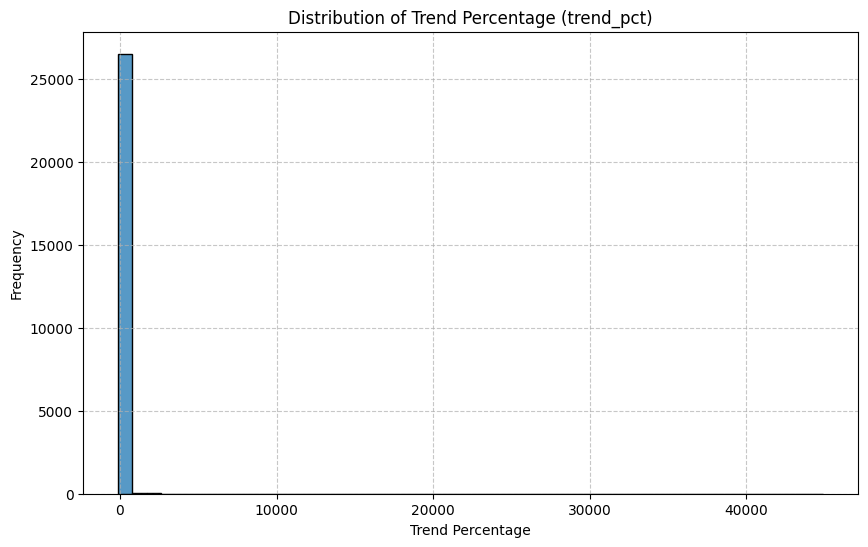

In [19]:
# Code to support Task 2: Target or Proxy
# The target variable is 'trend_pct'. Inspecting its distribution and characteristics.

import matplotlib.pyplot as plt
import seaborn as sns

print("Descriptive statistics for the target variable 'trend_pct':")
display(df['trend_pct'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['trend_pct'], bins=50)
plt.title('Distribution of Trend Percentage (trend_pct)')
plt.xlabel('Trend Percentage')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 3. Success metric

*One metric you can defend. What number means 'good'?*

Precision@K is the chosen success metric for this ML ranking task. 'K' would be determined based on editor capacity and 'relevant' items are defined from the `trend_pct` or `is_declining_label` to measure the model's effectiveness in identifying pages truly in need of intervention.

A 'good' value for Precision@K signifies that a high percentage of the top `K` pages recommended by the ML model are indeed 'relevant'—meaning they are genuinely in need of intervention or experiencing a significant decline in engagement. For example, if K=100 and Precision@K is 0.85, it means that 85 of the 100 pages flagged by the model are truly problematic and require editorial attention.


### Supporting Code Explanation for Task 3: Success Metric (Precision@K)

To concretely evaluate `Precision@K`, we would first need to define what constitutes a 'relevant' item based on our target variable `trend_pct` or a derived `is_declining_label`. For example, if we consider pages with `trend_pct` below a certain negative threshold (e.g., less than -10%) as 'relevant', we can quantify the number of such pages in our dataset. Once the model predicts a 'priority score' for each content item, we would rank them, select the top `K`, and then measure how many of these `K` items are truly 'relevant'.

In [20]:
# Example of how 'relevant' items might be defined for Precision@K
# For illustrative purposes only, as 'K' is not yet defined and no model has been trained.

# Define a threshold for 'relevance' based on trend_pct
relevance_threshold = -10 # Example: pages with trend_pct < -10 are considered 'relevant' (declining significantly)
df['is_relevant'] = df['trend_pct'] < relevance_threshold

print(f"Number of 'relevant' pages (trend_pct < {relevance_threshold}%): {df['is_relevant'].sum()}")
print(f"Percentage of 'relevant' pages: {df['is_relevant'].mean() * 100:.2f}%")

# This 'is_relevant' flag would then be used to calculate Precision@K after model ranking.
# A high Precision@K would mean that a significant portion of the top 'K' pages recommended by the model are indeed marked as 'is_relevant'.

Number of 'relevant' pages (trend_pct < -10%): 18248
Percentage of 'relevant' pages: 60.83%


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

### Unit of Analysis Explanation

Based on the problem framing, the intended unit of analysis for this ML ranking task is **one row per content item**, uniquely identified by `content_id`. The data inspection revealed that `df['content_id'].duplicated().any()` evaluates to `False`, meaning there are no duplicate `content_id` values in the dataset. This confirms that each row in the DataFrame represents a distinct content item.

Therefore, the DataFrame directly supports the unit of analysis as 'one row = one content item'. This structure is ideal for our ranking task, as we aim to assign a single priority score to each unique `content_id`, which can then be used to rank and recommend pages for editorial intervention.

In [21]:
import pandas as pd

df = pd.read_csv('/content/content_refresh_anonymized.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print(f"\nShape of the DataFrame: {df.shape}")

is_content_id_unique = df['content_id'].duplicated().any()
print(f"\nAre there any duplicate 'content_id' values? {is_content_id_unique}")

First 5 rows of the DataFrame:
             content_id          client_id  search_volume  competition  \
0  content_304f48230142  client_f369cb89fc           10.0         0.67   
1  content_a1fb4e703a9e  client_4e07408562           90.0         0.01   
2  content_9aa793d4d895  client_7f2253d7e2            0.0         0.00   
3  content_331d6c4de07b  client_19581e27de           10.0         0.00   
4  content_d99b7a2d90ca  client_3fdba35f04            0.0         0.00   

  competition_level   cpc     content_type    main_intent  word_count  \
0              HIGH  2.05  keyword article  transactional      3221.0   
1               LOW  0.05  keyword article  informational      2481.0   
2               LOW  0.00  keyword article  informational      3515.0   
3               LOW  0.00  keyword article     commercial         NaN   
4               LOW  0.00  keyword article  informational      2803.0   

   char_count  ... char_count_tier   ctr  avg_position  engagement_rate  \
0     2045

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

A machine learning approach is superior to a fixed rule (or a series of if-statements) for this content refresh task due to several key factors derived from our problem framing:

1.  **Multifaceted Nature of Content Decline:** As observed in Task 4, our dataset contains 44 different features (columns) for each `content_id`. These features cover various aspects like `search_volume`, `competition`, `content_type`, `engagement_rate`, `scroll_rate`, `ai_traffic_pct`, `impression_tier`, and `position_tier`. A fixed rule would struggle to incorporate the complex, non-linear interactions between these numerous variables that contribute to a page's `trend_pct` (our target variable from Task 2).

2.  **Continuous and Nuanced Target Variable:** The target variable, `trend_pct`, is continuous. While we define 'relevant' for `Precision@K` (Task 3) based on a threshold (e.g., pages with `trend_pct` < -0.10), the underlying problem requires ranking by a 'priority score'. A fixed rule can only classify (e.g., 'fix' vs. 'don't fix') based on simple thresholds, failing to provide the granular prioritization needed to select the *best* `K` pages out of many potential candidates for an editor.

3.  **Optimization for `Precision@K`:** Our chosen success metric, `Precision@K` (Task 3), explicitly aims to maximize the proportion of truly relevant items within the top `K` recommendations. A hand-coded set of if-else statements is unlikely to be optimized for this specific ranking objective. An ML model, especially a ranking model, can learn to discern subtle patterns and interactions among features to produce a ranked list that maximizes this metric, effectively guiding editors to the most impactful work.

4.  **Adaptability to Evolving Patterns:** Content performance metrics and user behavior can shift over time. A fixed rule would require constant manual adjustment and re-evaluation. An ML model, however, can be retrained periodically on new data to adapt to these evolving patterns, maintaining its effectiveness without constant human intervention in its logic.

In essence, the complexity of identifying declining content, the need for a continuous priority score, and the specific optimization goal of `Precision@K` all point to machine learning as a more robust, adaptable, and performant solution compared to a static, fixed-rule system.

In [22]:
# Code to support Task 5: Why ML Beats a Fixed Rule Here
# One of the reasons ML is superior is the 'Multifaceted Nature' of the data.
# Let's count the number of potential features available in our DataFrame.

# Excluding identifiers and target variables to get a count of potential features.
excluded_for_features = ['content_id', 'client_id', 'trend_pct', 'trend_direction']
feature_columns = [col for col in df.columns if col not in excluded_for_features]

print(f"Total number of columns in the DataFrame: {df.shape[1]}")
print(f"Number of columns identified as potential features for the ML model: {len(feature_columns)}")
print("Example potential features (first 5):", feature_columns[:5])

# The presence of 40 distinct features, each potentially interacting
# in complex ways, makes a fixed-rule system impractical and highly inefficient to develop
# and maintain compared to an ML model that can learn these relationships automatically.

Total number of columns in the DataFrame: 44
Number of columns identified as potential features for the ML model: 40
Example potential features (first 5): ['search_volume', 'competition', 'competition_level', 'cpc', 'content_type']


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.